Loaded 2 sheets. Final shape: (1067371, 8)
CLEANING FUNCTION IS RUNNING
<class 'pandas.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  object        
 1   StockCode    779425 non-null  object        
 2   Description  779425 non-null  object        
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[us]
 5   Price        779425 non-null  float64       
 6   Customer_ID  779425 non-null  float64       
 7   Country      779425 non-null  str           
 8   Revenue      779425 non-null  float64       
 9   YearMonth    779425 non-null  period[M]     
dtypes: datetime64[us](1), float64(3), int64(1), object(3), period[M](1), str(1)
memory usage: 65.4+ MB
Country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e

,Orders,Revenue,Revenue_per_Order
Country,,,
United Kingdom,33541,1.438923e+07,429.004350
EIRE,567,6.165705e+05,1087.425996
Netherlands,228,5.540381e+05,2429.991623
Germany,789,4.250197e+05,538.681510
France,614,3.487690e+05,568.027622


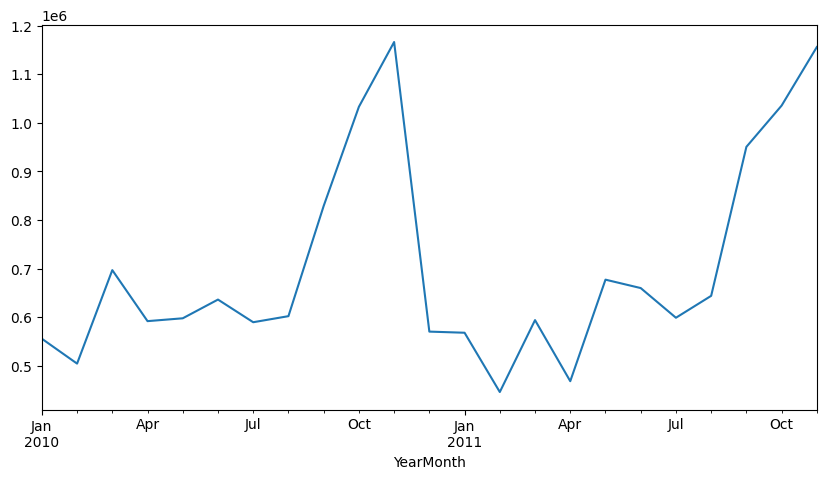

In [2]:
import sys
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(PROJECT_ROOT)

from src.data.data_loader import load_data
from src.data.data_cleaning import clean_data
from src.features.feature_engineering import add_features
from src.analysis.analysis import (
    get_monthly_sales,
    get_top_countries,
    get_top_products,
    country_metrics,
    orders_vs_revenue
)
from src.analysis.analysis import avg_order_value_by_country

df = load_data('../data/online_retail_II.xlsx')
df = clean_data(df)
df = add_features(df)

df.shape
df.info()

monthly_sales = get_monthly_sales(df)
monthly_sales.plot(figsize=(10,5))

top_countries_df = get_top_countries(df)
top_products_df = get_top_products(df)

print(top_countries_df)
print(top_products_df)

country_metrics(df).head()
orders_vs_revenue(df).head()

In [3]:
print(df.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer_ID', 'Country', 'Revenue', 'YearMonth'],
      dtype='str')


In [4]:
from src.data.data_loader import load_data

print(load_data)

<function load_data at 0x000001A2D7A250C0>


In [5]:
country_df = country_metrics(df)
print(country_df.head(10))

             Customer_ID    Revenue  AvgRevenuePerCustomer
Country                                                   
EIRE                   5  616570.54          123314.108000
Singapore              1   25317.06           25317.060000
Netherlands           22  554038.09           25183.549545
Australia             15  169283.46           11285.564000
Denmark               12   68580.69            5715.057500
Iceland                1    4921.53            4921.530000
Lithuania              1    4892.68            4892.680000
Sweden                19   91515.82            4816.622105
Switzerland           22  100061.94            4548.270000
Norway                13   56322.50            4332.500000


In [6]:
comparison_df = orders_vs_revenue(df)
print(comparison_df.head(10))

                Orders       Revenue  Revenue_per_Order
Country                                                
United Kingdom   33541  1.438923e+07         429.004350
EIRE               567  6.165705e+05        1087.425996
Netherlands        228  5.540381e+05        2429.991623
Germany            789  4.250197e+05         538.681510
France             614  3.487690e+05         568.027622
Australia           95  1.692835e+05        1781.931158
Spain              154  1.083325e+05         703.457727
Switzerland         90  1.000619e+05        1111.799333
Sweden             104  9.151582e+04         879.959808
Denmark             43  6.858069e+04        1594.899767


In [7]:
aov_df = avg_order_value_by_country(df)
print(aov_df.head(10))

Country
Netherlands    2429.991623
Singapore      2301.550909
Australia      1781.931158
Lebanon        1693.880000
Denmark        1594.899767
Thailand       1535.270000
Israel         1487.891429
Japan          1303.754848
Norway         1251.611111
Switzerland    1111.799333
Name: AvgOrderValue, dtype: float64


In [8]:
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer_ID', 'Country', 'Revenue', 'YearMonth']


In [9]:
from src.features.rfm import compute_rfm

rfm = compute_rfm(df)
rfm.head()

,Recency,Frequency,Monetary
Customer_ID,,,
12346.0,326,12,207.40
12347.0,2,8,554.57
12348.0,75,5,193.10
12349.0,19,4,1480.44
12350.0,310,1,65.30


In [10]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [11]:
from src.data.data_loader import load_data
from src.data.data_cleaning import clean_data
from src.features.rfm import compute_rfm
from src.models.segmentation import cluster_rfm
from src.models.segmentation import segment_customers
import os
import sys

df = load_data('../data/online_retail_II.xlsx')
import pandas as pd
df = clean_data(df)

rfm = compute_rfm(df)
rfm = cluster_rfm(rfm)
rfm = segment_customers(rfm)

Loaded 2 sheets. Final shape: (1067371, 8)
CLEANING FUNCTION IS RUNNING


In [12]:
print(df.shape)
print(df['InvoiceDate'].min(), df['InvoiceDate'].max())
print(df['InvoiceDate'].dt.year.unique())

(779425, 8)
2009-12-01 07:45:00 2011-12-09 12:50:00
[2009 2010 2011]


In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  object        
 1   StockCode    779425 non-null  object        
 2   Description  779425 non-null  object        
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[us]
 5   Price        779425 non-null  float64       
 6   Customer_ID  779425 non-null  float64       
 7   Country      779425 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 53.5+ MB


<Axes: xlabel='YearMonth'>

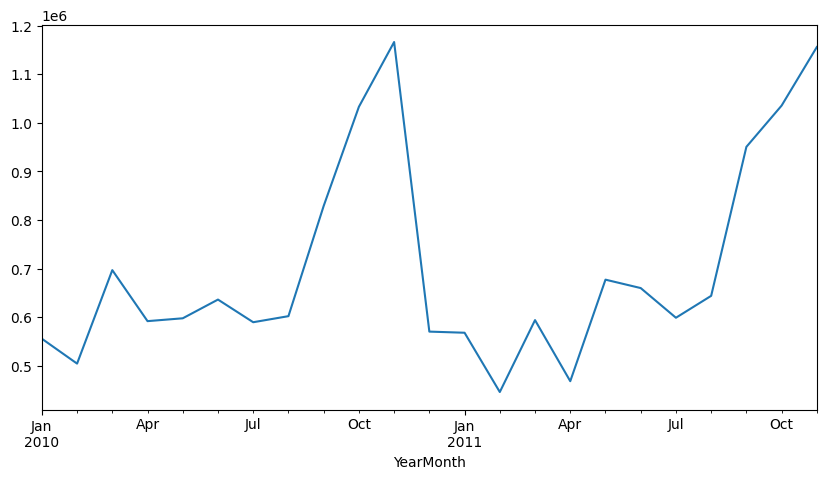

In [14]:
monthly_sales.plot(figsize=(10,5))

In [15]:
print(top_countries_df)

Country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.487690e+05
Name: Revenue, dtype: float64


In [16]:
print(top_products_df)

Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                151777.67
JUMBO BAG RED RETROSPOT               134307.44
Name: Revenue, dtype: float64


In [17]:
df.describe()

,Quantity,InvoiceDate,Price,Customer_ID
count,779425.000000,779425,779425.000000,779425.000000
mean,13.489370,2011-01-03 01:44:42.593476,3.218488,15320.360461
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000
25%,2.000000,2010-07-02 14:39:00,1.250000,13971.000000
50%,6.000000,2010-12-02 14:09:00,1.950000,15247.000000
75%,12.000000,2011-08-01 13:44:00,3.750000,16794.000000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000
std,145.855814,NaN,29.676140,1695.692775


In [18]:
from src.features.rfm import clean_data, add_total_price, compute_rfm

df = clean_data(df)
df = add_total_price(df)

rfm = compute_rfm(df)

rfm.head()

,Recency,Frequency,Monetary
Customer_ID,,,
12346.0,326,12,207.40
12347.0,2,8,554.57
12348.0,75,5,193.10
12349.0,19,4,1480.44
12350.0,310,1,65.30


In [19]:
# CLUSTERING 
from src.features.rfm import clean_data, add_total_price, compute_rfm
from src.models.segmentation import remove_outliers, cluster_rfm, label_segments

df = clean_data(df)
df = add_total_price(df)

rfm = compute_rfm(df)

rfm = remove_outliers(rfm)
rfm = cluster_rfm(rfm)
rfm = label_segments(rfm)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
Customer_ID,,,,,
12346.0,326,12,207.40,3,Lost Customers
12347.0,2,8,554.57,3,Regular Customers
12348.0,75,5,193.10,1,At Risk Customers
12349.0,19,4,1480.44,3,At Risk Customers
12350.0,310,1,65.30,0,Lost Customers


In [20]:
rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,477.665577,1.997277,122.231150
1,88.625601,3.317795,178.273924
2,30.812261,22.291188,1801.972693
3,55.679581,11.351832,740.329491


In [21]:
rfm['Segment'].value_counts()

Segment
Lost Customers       2259
At Risk Customers    1970
Regular Customers    1191
VIP Customers         335
Name: count, dtype: int64

In [22]:
rfm['Cluster'].value_counts()

Cluster
1    2703
0    1836
3     955
2     261
Name: count, dtype: int64

Segment
At Risk Customers    369656.724
Lost Customers       320121.162
Regular Customers    642704.425
VIP Customers        551138.034
Name: Monetary, dtype: float64

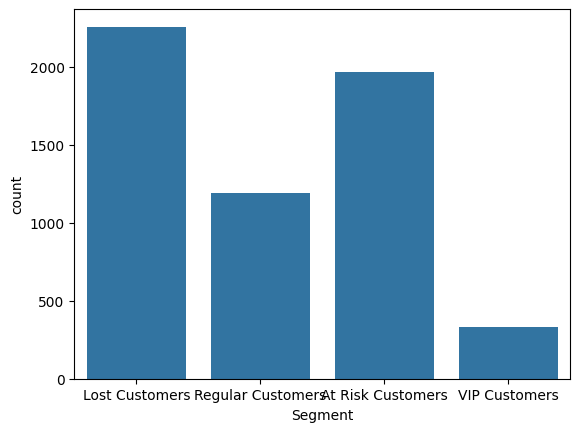

In [23]:
# Time-Series (Sales Forecasting)
from src.models.forecasting import compute_daily_sales
from src.analysis.analysis import segment_revenue

daily_sales = compute_daily_sales(df)

rfm.head()
rfm['Segment'].value_counts()

import seaborn as sns
sns.countplot(x='Segment', data=rfm)

segment_revenue(rfm)


In [24]:
rfm.head()
rfm['Segment'].value_counts()

Segment
Lost Customers       2259
At Risk Customers    1970
Regular Customers    1191
VIP Customers         335
Name: count, dtype: int64

<Axes: xlabel='Segment', ylabel='count'>

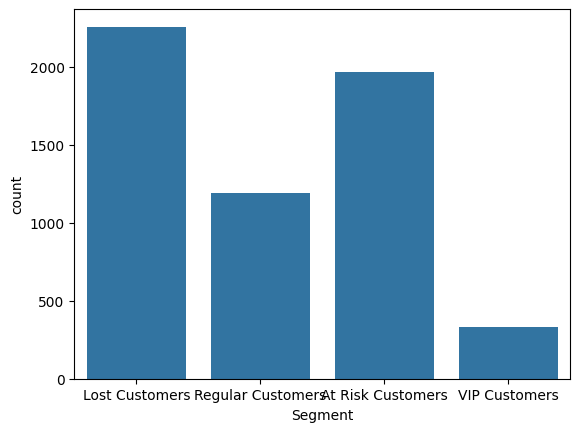

In [25]:
import seaborn as sns
sns.countplot(x='Segment', data=rfm)

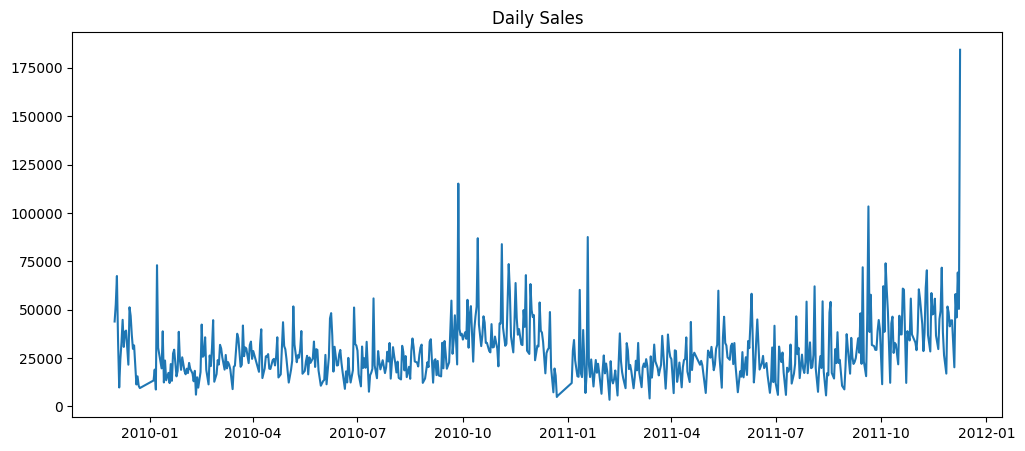

In [26]:
from src.models.forecasting import compute_daily_sales

daily_sales = compute_daily_sales(df)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(daily_sales['Date'], daily_sales['TotalPrice'])
plt.title("Daily Sales")
plt.show()

20:29:46 - cmdstanpy - INFO - Chain [1] start processing
20:29:46 - cmdstanpy - INFO - Chain [1] done processing


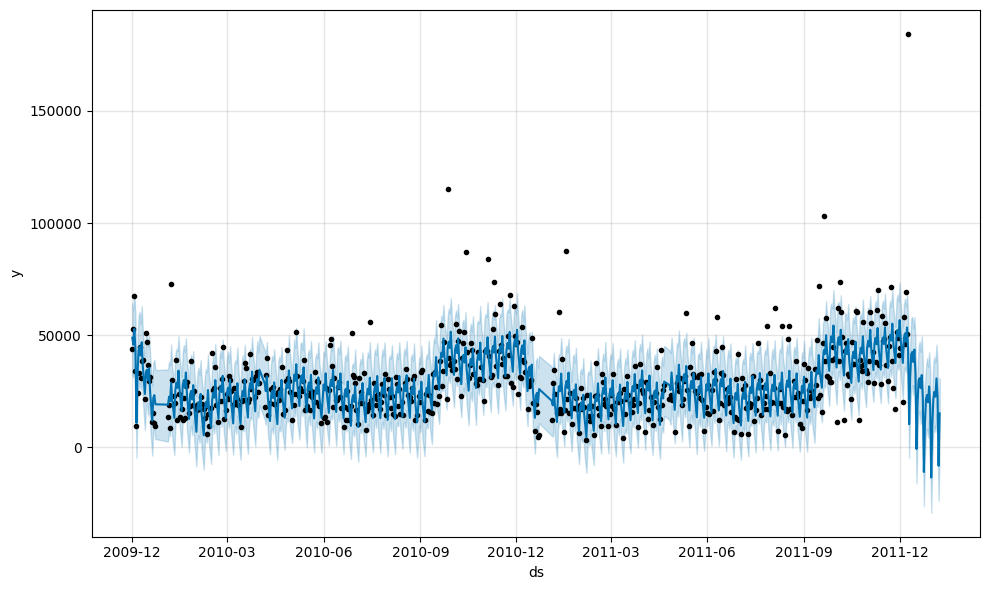

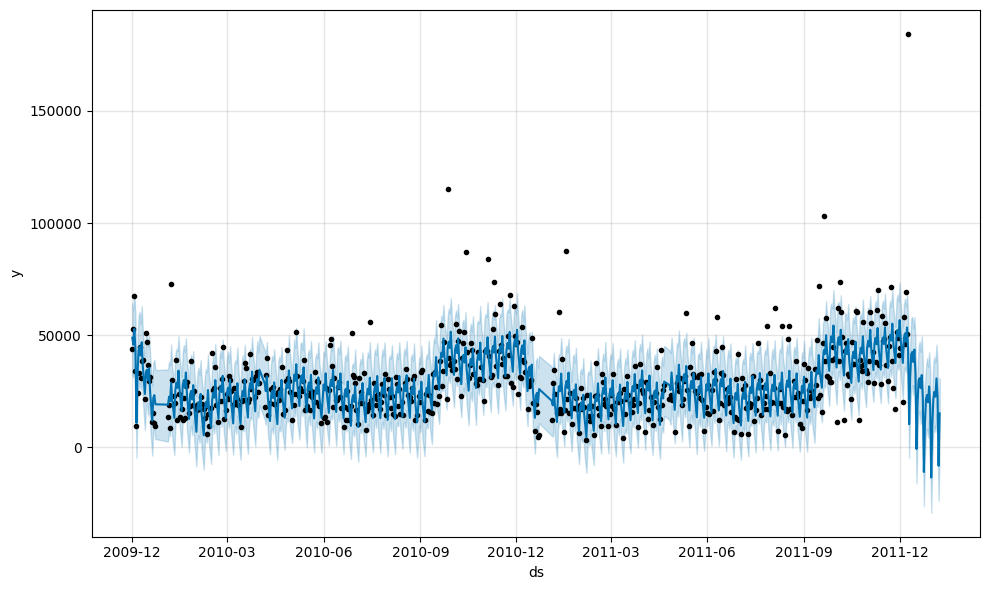

In [27]:
from prophet import Prophet

# Prophet needs specific column names
ts = daily_sales.rename(columns={'Date': 'ds', 'TotalPrice': 'y'})

model = Prophet()
model.fit(ts)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

model.plot(forecast)

In [28]:
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
print(cluster_summary)

            Recency  Frequency     Monetary
Cluster                                    
0        477.665577   1.997277   122.231150
1         88.625601   3.317795   178.273924
2         30.812261  22.291188  1801.972693
3         55.679581  11.351832   740.329491


In [29]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

db = DBSCAN(eps=0.5, min_samples=5)
rfm['DB_Cluster'] = db.fit_predict(rfm_scaled)

In [30]:
# Which segment drives revenue?
rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

# Which segment is declining?
# (compare recent vs past behavior if possible)

Segment
Regular Customers    642704.425
VIP Customers        551138.034
At Risk Customers    369656.724
Lost Customers       320121.162
Name: Monetary, dtype: float64

Text(0.5, 1.0, '30-Day Sales Forecast')

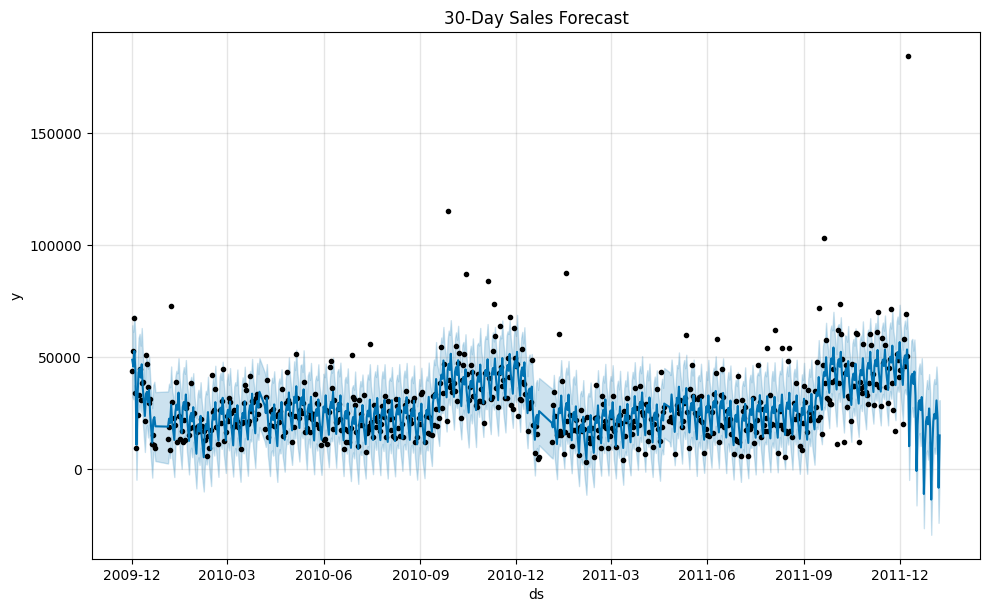

In [31]:
model.plot(forecast)
plt.title("30-Day Sales Forecast")

In [32]:
daily_sales.tail()

,Date,TotalPrice
599,2011-12-05,58081.09
600,2011-12-06,45989.66
601,2011-12-07,69230.60
602,2011-12-08,50395.96
603,2011-12-09,184347.66


In [33]:
df = load_data('../data/online_retail_II.xlsx')
print(df.shape)
print(df.head())

Loaded 2 sheets. Final shape: (1067371, 8)
(1067371, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [34]:
df_clean = clean_data(df)

print(df_clean.shape)
print(df_clean.isnull().sum())

(1044421, 8)
Invoice             0
StockCode           0
Description      1693
Quantity            0
InvoiceDate         0
Price               0
CustomerID     238801
Country             0
dtype: int64


In [35]:
df_feat = add_features(df_clean)

print(df_feat.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'CustomerID', 'Country', 'Revenue', 'YearMonth'],
      dtype='str')


In [36]:
monthly_sales = get_monthly_sales(df_feat)
print(monthly_sales.head())

YearMonth
2010-01    652708.502
2010-02    553713.306
2010-03    833570.131
2010-04    627934.632
2010-05    659858.860
Freq: M, Name: Revenue, dtype: float64


In [37]:
print(df_feat['Quantity'].sum())
print(df_feat['Price'].mean())

11672570
3.9143756377935714


<Axes: xlabel='YearMonth'>

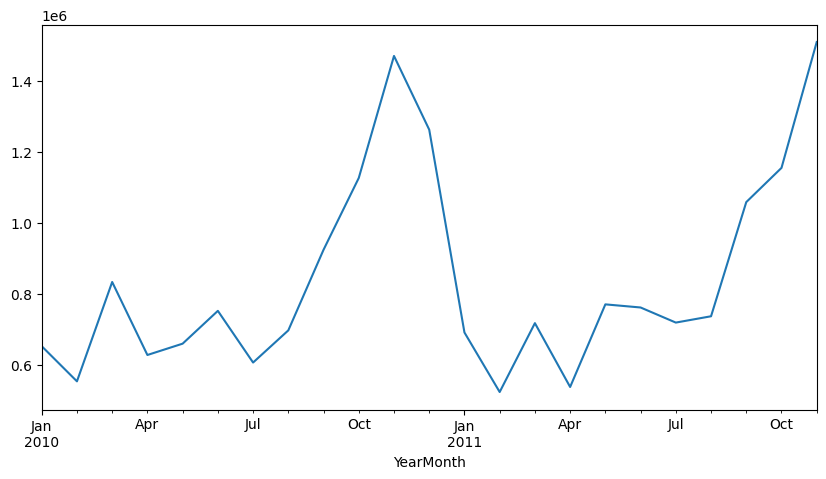

In [38]:
monthly_sales.plot(figsize=(10,5))

In [39]:
def run_pipeline(path):
    df = load_data(path)
    df = clean_data(df)
    df = add_features(df)
    return df

In [40]:
df_final = run_pipeline('../data/online_retail_II.xlsx')

print(df_final.shape)
print(df_final.head())

Loaded 2 sheets. Final shape: (1067371, 8)
(1044421, 10)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  CustomerID         Country  Revenue YearMonth  
0 2009-12-01 07:45:00   6.95     13085.0  United Kingdom     83.4   2009-12  
1 2009-12-01 07:45:00   6.75     13085.0  United Kingdom     81.0   2009-12  
2 2009-12-01 07:45:00   6.75     13085.0  United Kingdom     81.0   2009-12  
3 2009-12-01 07:45:00   2.10     13085.0  United Kingdom    100.8   2009-12  
4 2009-12-01 07:45:00   1.25     13085.0  United Kingdom     30.0   2009-12  


In [41]:
path = '../data/online_retail_II.xlsx'

df1 = run_pipeline(path)
df2 = run_pipeline(path)

Loaded 2 sheets. Final shape: (1067371, 8)
Loaded 2 sheets. Final shape: (1067371, 8)


In [42]:
print(df1.describe())
print(df1.isnull().sum())
print(df1.head())

           Quantity                 InvoiceDate         Price     CustomerID  \
count  1.044421e+06                     1044421  1.044421e+06  805620.000000   
mean   1.117612e+01  2011-01-03 13:08:35.693996  3.914376e+00   15331.856250   
min    1.000000e+00         2009-12-01 07:45:00 -5.359436e+04   12346.000000   
25%    1.000000e+00         2010-07-11 14:19:00  1.250000e+00   13982.000000   
50%    3.000000e+00         2010-12-07 15:32:00  2.100000e+00   15271.000000   
75%    1.000000e+01         2011-07-24 11:25:00  4.130000e+00   16805.000000   
max    8.099500e+04         2011-12-09 12:50:00  2.511109e+04   18287.000000   
std    1.294560e+02                         NaN  9.451415e+01    1696.768395   

            Revenue  
count  1.044421e+06  
mean   1.992902e+01  
min   -5.359436e+04  
25%    3.900000e+00  
50%    9.960000e+00  
75%    1.770000e+01  
max    1.684696e+05  
std    2.178222e+02  
Invoice             0
StockCode           0
Description      1693
Quantity       

In [43]:
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

In [45]:
df = df.dropna(subset=['Customer ID'])

In [1]:
from src.features.rfm import compute_rfm
from src.data.data_loader import load_data  # or however you load df

df = load_data()
rfm = compute_rfm(df)

print(rfm.columns)
print(rfm.head())

ModuleNotFoundError: No module named 'src'